# Library

In [1]:
import pandas as pd

# Load Datasets that have been collected from three genres

In this section, the game datasets that have been collected are loaded, after which lowercase letters are applied in the genre section to filter your genre by removing sub-genres that are not related to adventure, casual and sport.

In [2]:
# Load adventure game datasets
game_datasets = pd.read_csv('/content/adventure_games_data.csv')

game_datasets['genres'] = game_datasets['genres'].str.lower()
adventure_games = game_datasets[game_datasets['genres'].str.contains('adventure')]
adventure_games['genres'] = 'adventure'

# Save the datasets with new file csv
adventure_games.to_csv('adventure_games_genre.csv', index=False)

# Show several datasets
adventure_games


,title,genres,description
0,PUBG: BATTLEGROUNDS,adventure,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ..."
1,Apex Legends™,adventure,APEX LEGENDS: FROM THE RIFT About the Game Con...
2,Palworld,adventure,"Q. What kind of game is this? A. In this game,..."
3,New World: Aeternum,adventure,NEW WORLD: AETERNUM GAME UPDATE A major update...
4,Black Myth: Wukong,adventure,Digital Deluxe Edition The Black Myth: Wukong ...
...,...,...,...
495,Reign of Guilds,adventure,JOIN OUR COMMUNITY About the Game TRY THE GAME...
496,Tower Unite,adventure,"Tower Unite is a living, evolving world, fuele..."
497,Biped,adventure,"Two little bipedal robots, Aku and Sila, will ..."
498,NGU IDLE,adventure,Everyone likes numbers that go up. Play NGU ID...


In [3]:
# Load casual game datasets
game_datasets = pd.read_csv('/content/casual_games_data.csv')

game_datasets['genres'] = game_datasets['genres'].str.lower()
casual_games = game_datasets[game_datasets['genres'].str.contains('casual')]
casual_games['genres'] = 'casual'

# Save the datasets with new file csv
casual_games.to_csv('casual_games_genre.csv', index=False)

# Show several datasets
casual_games


,title,genres,description
0,Wallpaper Engine,casual,Wallpaper Engine enables you to use live wallp...
1,Garry's Mod,casual,Garry's Mod is a physics sandbox. There aren't...
2,Among Us,casual,Play with 4-15 player online or via local WiFi...
3,Unturned,casual,STAY UNTURNED You're one of the few not yet tu...
4,Fall Guys,casual,You’re invited to dive and dodge your way to v...
...,...,...,...
495,Influent Language Learning Game,casual,Definitive Edition All 23 Languages now includ...
496,Shieldwall,casual,Shieldwall is a funny third-person tactical ba...
497,House Flipper 2,casual,It doesn't matter if you're a makeover veteran...
498,KartKraft™,casual,New KartKraft Content Today! Experience a whol...


In [4]:
# Load sport game datasets
game_datasets = pd.read_csv('/content/sports_games_data.csv')

game_datasets['genres'] = game_datasets['genres'].str.lower()
sport_games = game_datasets[game_datasets['genres'].str.contains('sport')]
sport_games['genres'] = 'sport'

# Save the datasets with new file csv
sport_games.to_csv('sports_games_genre.csv', index=False)

# Show several file
sport_games


,title,genres,description
0,Fall Guys,sport,You’re invited to dive and dodge your way to v...
1,Rocket League®,sport,Rocket League is a high-powered hybrid of arca...
2,VRChat,sport,Imagine a space filled with limitless possibil...
3,Street Warriors Online,sport,"This is the first, realistic PvP brawling game..."
4,EA SPORTS™ FIFA 23,sport,Join the Club with EA SPORTS FC™ 24 Highlights...
...,...,...,...
495,Premier Manager 04/05,sport,Being a manager is about getting the best out ...
496,Quiz Pro - Guess Pictures,sport,Quiz Pro - Guess Pictures Try to quess what is...
497,Bocce VR Simulator,sport,Check out our VR Games About the Game Bocce VR...
498,Matt's Project Zombies: Endless,sport,The year is 2077 and mankind is in peril. The ...


# Combine file

After filtering the genre by leaving only the main genre, in this section, we combine the three genres and delete several games that are considered duplicates based on their titles. After that, the final results of the datasets that will be used are seen.

In [ ]:
# Load Datasets
adventure_games = pd.read_csv('/content/adventure_games_genre.csv')
casual_games = pd.read_csv('/content/casual_games_genre.csv')
sport_games = pd.read_csv('/content/sports_games_genre.csv')

combined_games = pd.concat([adventure_games, casual_games, sport_games], ignore_index=True)
combined_games = combined_games.drop_duplicates(subset='title')

# Save combined file
combined_games.to_csv('combined_games_genre.csv', index=False)

# Showing final datasets for Preprocessing
combined_games


,title,genres,description
0,PUBG: BATTLEGROUNDS,adventure,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ..."
1,Apex Legends™,adventure,APEX LEGENDS: FROM THE RIFT About the Game Con...
2,Palworld,adventure,"Q. What kind of game is this? A. In this game,..."
3,New World: Aeternum,adventure,NEW WORLD: AETERNUM GAME UPDATE A major update...
4,Black Myth: Wukong,adventure,Digital Deluxe Edition The Black Myth: Wukong ...
...,...,...,...
1495,Premier Manager 04/05,sport,Being a manager is about getting the best out ...
1496,Quiz Pro - Guess Pictures,sport,Quiz Pro - Guess Pictures Try to quess what is...
1497,Bocce VR Simulator,sport,Check out our VR Games About the Game Bocce VR...
1498,Matt's Project Zombies: Endless,sport,The year is 2077 and mankind is in peril. The ...


In [6]:
# Load Datasets
game_datasets = pd.read_csv('/content/combined_games_genre.csv')

# View overall data totals
total_games = len(game_datasets)
print(f"Total games that have been collected: {total_games}")

# Counting the number of games per genre
genre_counts = game_datasets['genres'].value_counts()

print("\nNumber of games per genre:")
print(genre_counts)

Total games that have been collected: 1417

Number of games per genre:
genres
adventure    500
sport        474
casual       443
Name: count, dtype: int64


# Preprocessing

In this session, preprocessing of datasets is carried out so that it can be more accurate when classifying game genres by performing case folding, Stopword Removal, Tokenizing, and Stemming using Stemmer Snowball.

> Case Folding

the process of changing all letters in a text to lowercase to ensure consistency.

In [7]:
import re

def clean_text(game_datasets, text_field, new_text_field_name):
    # Convert to lowercase and handle non-string values
    game_datasets[new_text_field_name] = game_datasets[text_field].apply(lambda x: str(x).lower() if isinstance(x, str) else '')
    game_datasets[new_text_field_name] = game_datasets[new_text_field_name].apply(
        lambda elem: re.sub(r"(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)|^rt|http.?", "", elem)
    )
    game_datasets[new_text_field_name] = game_datasets[new_text_field_name].apply(lambda elem: re.sub(r"\d+", "", elem))
    return game_datasets

In [8]:
# Clean the text for 'title', 'genres', and 'description' columns again with the updated function
game_datasets_clean = clean_text(game_datasets, 'title', 'title_clean')
game_datasets_clean = clean_text(game_datasets_clean, 'genres', 'genre_clean')
game_datasets_clean = clean_text(game_datasets_clean, 'description', 'description_clean')

In [9]:
# Display the cleaned dataframe
game_datasets_clean.head(10)

,title,genres,description,title_clean,genre_clean,description_clean
0,PUBG: BATTLEGROUNDS,adventure,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",pubg battlegrounds,adventure,land loot survive play pubg battlegrounds for ...
1,Apex Legends™,adventure,APEX LEGENDS: FROM THE RIFT About the Game Con...,apex legends,adventure,apex legends from the rift about the game conq...
2,Palworld,adventure,"Q. What kind of game is this? A. In this game,...",palworld,adventure,q what kind of game is this a in this game you...
3,New World: Aeternum,adventure,NEW WORLD: AETERNUM GAME UPDATE A major update...,new world aeternum,adventure,new world aeternum game update a major update ...
4,Black Myth: Wukong,adventure,Digital Deluxe Edition The Black Myth: Wukong ...,black myth wukong,adventure,digital deluxe edition the black myth wukong d...
5,Grand Theft Auto V,adventure,"When a young street hustler, a retired bank ro...",grand theft auto v,adventure,when a young street hustler a retired bank rob...
6,Rust,adventure,The only aim in Rust is to survive. Everything...,rust,adventure,the only aim in rust is to survive everything ...
7,Terraria,adventure,"Dig, Fight, Explore, Build: The very world is ...",terraria,adventure,dig fight explore build the very world is at y...
8,Baldur's Gate 3,adventure,Gather your party and return to the Forgotten ...,baldurs gate,adventure,gather your party and return to the forgotten ...
9,ARK: Survival Evolved,adventure,ARK: Survival Ascended! Respawn into a new din...,ark survival evolved,adventure,ark survival ascended respawn into a new dinos...


> Stopword Removal

the process of removing common words that have no significant meaning in text analysis, such as "and," "the," or "is."

In [10]:
import nltk.corpus
nltk.download('stopwords')
from nltk.corpus import stopwords
stop = stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [11]:
# Define a function to remove stopwords
def remove_stopwords_from_text(text):
    if isinstance(text, str):
        return ' '.join([word for word in text.split() if word.lower() not in stop])
    return text

# Apply the function to 'title_clean', 'genre_clean', and 'description_clean' columns in game_datasets_clean
game_datasets_clean['title_clean_StopWord'] = game_datasets_clean['title_clean'].apply(remove_stopwords_from_text)
game_datasets_clean['genre_clean_StopWord'] = game_datasets_clean['genre_clean'].apply(remove_stopwords_from_text)
game_datasets_clean['description_clean_StopWord'] = game_datasets_clean['description_clean'].apply(remove_stopwords_from_text)


In [12]:
# Display the first 10 rows
game_datasets_clean.head(10)

,title,genres,description,title_clean,genre_clean,description_clean,title_clean_StopWord,genre_clean_StopWord,description_clean_StopWord
0,PUBG: BATTLEGROUNDS,adventure,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",pubg battlegrounds,adventure,land loot survive play pubg battlegrounds for ...,pubg battlegrounds,adventure,land loot survive play pubg battlegrounds free...
1,Apex Legends™,adventure,APEX LEGENDS: FROM THE RIFT About the Game Con...,apex legends,adventure,apex legends from the rift about the game conq...,apex legends,adventure,apex legends rift game conquer character apex ...
2,Palworld,adventure,"Q. What kind of game is this? A. In this game,...",palworld,adventure,q what kind of game is this a in this game you...,palworld,adventure,q kind game game peacefully live alongside mys...
3,New World: Aeternum,adventure,NEW WORLD: AETERNUM GAME UPDATE A major update...,new world aeternum,adventure,new world aeternum game update a major update ...,new world aeternum,adventure,new world aeternum game update major update ar...
4,Black Myth: Wukong,adventure,Digital Deluxe Edition The Black Myth: Wukong ...,black myth wukong,adventure,digital deluxe edition the black myth wukong d...,black myth wukong,adventure,digital deluxe edition black myth wukong digit...
5,Grand Theft Auto V,adventure,"When a young street hustler, a retired bank ro...",grand theft auto v,adventure,when a young street hustler a retired bank rob...,grand theft auto v,adventure,young street hustler retired bank robber terri...
6,Rust,adventure,The only aim in Rust is to survive. Everything...,rust,adventure,the only aim in rust is to survive everything ...,rust,adventure,aim rust survive everything wants die islands ...
7,Terraria,adventure,"Dig, Fight, Explore, Build: The very world is ...",terraria,adventure,dig fight explore build the very world is at y...,terraria,adventure,dig fight explore build world fingertips fight...
8,Baldur's Gate 3,adventure,Gather your party and return to the Forgotten ...,baldurs gate,adventure,gather your party and return to the forgotten ...,baldurs gate,adventure,gather party return forgotten realms tale fell...
9,ARK: Survival Evolved,adventure,ARK: Survival Ascended! Respawn into a new din...,ark survival evolved,adventure,ark survival ascended respawn into a new dinos...,ark survival evolved,adventure,ark survival ascended respawn new dinosaur sur...


> Tokenizing

the process of breaking down text into smaller units, such as words or sentences, called tokens.

In [13]:
import nltk
nltk.download('punkt')
from nltk.tokenize import sent_tokenize, word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [14]:
# Filling empty values ​​in 'title_clean_StopWord' and 'description_clean_StopWord' columns with empty strings to avoid errors
game_datasets_clean['title_clean_StopWord'] = game_datasets_clean['title_clean_StopWord'].fillna('')
game_datasets_clean['description_clean_StopWord'] = game_datasets_clean['description_clean_StopWord'].fillna('')

# Tokenization of 'title_clean_StopWord' and 'description_clean_StopWord' columns
game_datasets_clean['title_tokens'] = game_datasets_clean['title_clean_StopWord'].apply(lambda x: re.findall(r'\b\w+\b', x))
game_datasets_clean['description_tokens'] = game_datasets_clean['description_clean_StopWord'].apply(lambda x: re.findall(r'\b\w+\b', x))


In [15]:
# Display the first 10 rows
game_datasets_clean.head(10)

,title,genres,description,title_clean,genre_clean,description_clean,title_clean_StopWord,genre_clean_StopWord,description_clean_StopWord,title_tokens,description_tokens
0,PUBG: BATTLEGROUNDS,adventure,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",pubg battlegrounds,adventure,land loot survive play pubg battlegrounds for ...,pubg battlegrounds,adventure,land loot survive play pubg battlegrounds free...,"[pubg, battlegrounds]","[land, loot, survive, play, pubg, battleground..."
1,Apex Legends™,adventure,APEX LEGENDS: FROM THE RIFT About the Game Con...,apex legends,adventure,apex legends from the rift about the game conq...,apex legends,adventure,apex legends rift game conquer character apex ...,"[apex, legends]","[apex, legends, rift, game, conquer, character..."
2,Palworld,adventure,"Q. What kind of game is this? A. In this game,...",palworld,adventure,q what kind of game is this a in this game you...,palworld,adventure,q kind game game peacefully live alongside mys...,[palworld],"[q, kind, game, game, peacefully, live, alongs..."
3,New World: Aeternum,adventure,NEW WORLD: AETERNUM GAME UPDATE A major update...,new world aeternum,adventure,new world aeternum game update a major update ...,new world aeternum,adventure,new world aeternum game update major update ar...,"[new, world, aeternum]","[new, world, aeternum, game, update, major, up..."
4,Black Myth: Wukong,adventure,Digital Deluxe Edition The Black Myth: Wukong ...,black myth wukong,adventure,digital deluxe edition the black myth wukong d...,black myth wukong,adventure,digital deluxe edition black myth wukong digit...,"[black, myth, wukong]","[digital, deluxe, edition, black, myth, wukong..."
5,Grand Theft Auto V,adventure,"When a young street hustler, a retired bank ro...",grand theft auto v,adventure,when a young street hustler a retired bank rob...,grand theft auto v,adventure,young street hustler retired bank robber terri...,"[grand, theft, auto, v]","[young, street, hustler, retired, bank, robber..."
6,Rust,adventure,The only aim in Rust is to survive. Everything...,rust,adventure,the only aim in rust is to survive everything ...,rust,adventure,aim rust survive everything wants die islands ...,[rust],"[aim, rust, survive, everything, wants, die, i..."
7,Terraria,adventure,"Dig, Fight, Explore, Build: The very world is ...",terraria,adventure,dig fight explore build the very world is at y...,terraria,adventure,dig fight explore build world fingertips fight...,[terraria],"[dig, fight, explore, build, world, fingertips..."
8,Baldur's Gate 3,adventure,Gather your party and return to the Forgotten ...,baldurs gate,adventure,gather your party and return to the forgotten ...,baldurs gate,adventure,gather party return forgotten realms tale fell...,"[baldurs, gate]","[gather, party, return, forgotten, realms, tal..."
9,ARK: Survival Evolved,adventure,ARK: Survival Ascended! Respawn into a new din...,ark survival evolved,adventure,ark survival ascended respawn into a new dinos...,ark survival evolved,adventure,ark survival ascended respawn new dinosaur sur...,"[ark, survival, evolved]","[ark, survival, ascended, respawn, new, dinosa..."


> Stemming using Snowball Stemmer

the process of changing a word into its basic form (stem) using the Snowball Stemmer algorithm. Snowball Stemmer is designed to cut off the endings of words in certain languages, such as English, so that words that have the same meaning but in different forms can be treated consistently.

In [16]:
from nltk.stem import SnowballStemmer
import re
snowball = SnowballStemmer("english")

In [17]:
# Applying stemming to 'title_tokens' and 'description_tokens' columns
game_datasets_clean['title_snowball'] = game_datasets_clean['title_tokens'].apply(lambda tokens: [snowball.stem(token) for token in tokens])
game_datasets_clean['description_snowball'] = game_datasets_clean['description_tokens'].apply(lambda tokens: [snowball.stem(token) for token in tokens])

In [18]:
game_datasets_clean.head(10)

,title,genres,description,title_clean,genre_clean,description_clean,title_clean_StopWord,genre_clean_StopWord,description_clean_StopWord,title_tokens,description_tokens,title_snowball,description_snowball
0,PUBG: BATTLEGROUNDS,adventure,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",pubg battlegrounds,adventure,land loot survive play pubg battlegrounds for ...,pubg battlegrounds,adventure,land loot survive play pubg battlegrounds free...,"[pubg, battlegrounds]","[land, loot, survive, play, pubg, battleground...","[pubg, battleground]","[land, loot, surviv, play, pubg, battleground,..."
1,Apex Legends™,adventure,APEX LEGENDS: FROM THE RIFT About the Game Con...,apex legends,adventure,apex legends from the rift about the game conq...,apex legends,adventure,apex legends rift game conquer character apex ...,"[apex, legends]","[apex, legends, rift, game, conquer, character...","[apex, legend]","[apex, legend, rift, game, conquer, charact, a..."
2,Palworld,adventure,"Q. What kind of game is this? A. In this game,...",palworld,adventure,q what kind of game is this a in this game you...,palworld,adventure,q kind game game peacefully live alongside mys...,[palworld],"[q, kind, game, game, peacefully, live, alongs...",[palworld],"[q, kind, game, game, peac, live, alongsid, my..."
3,New World: Aeternum,adventure,NEW WORLD: AETERNUM GAME UPDATE A major update...,new world aeternum,adventure,new world aeternum game update a major update ...,new world aeternum,adventure,new world aeternum game update major update ar...,"[new, world, aeternum]","[new, world, aeternum, game, update, major, up...","[new, world, aeternum]","[new, world, aeternum, game, updat, major, upd..."
4,Black Myth: Wukong,adventure,Digital Deluxe Edition The Black Myth: Wukong ...,black myth wukong,adventure,digital deluxe edition the black myth wukong d...,black myth wukong,adventure,digital deluxe edition black myth wukong digit...,"[black, myth, wukong]","[digital, deluxe, edition, black, myth, wukong...","[black, myth, wukong]","[digit, delux, edit, black, myth, wukong, digi..."
5,Grand Theft Auto V,adventure,"When a young street hustler, a retired bank ro...",grand theft auto v,adventure,when a young street hustler a retired bank rob...,grand theft auto v,adventure,young street hustler retired bank robber terri...,"[grand, theft, auto, v]","[young, street, hustler, retired, bank, robber...","[grand, theft, auto, v]","[young, street, hustler, retir, bank, robber, ..."
6,Rust,adventure,The only aim in Rust is to survive. Everything...,rust,adventure,the only aim in rust is to survive everything ...,rust,adventure,aim rust survive everything wants die islands ...,[rust],"[aim, rust, survive, everything, wants, die, i...",[rust],"[aim, rust, surviv, everyth, want, die, island..."
7,Terraria,adventure,"Dig, Fight, Explore, Build: The very world is ...",terraria,adventure,dig fight explore build the very world is at y...,terraria,adventure,dig fight explore build world fingertips fight...,[terraria],"[dig, fight, explore, build, world, fingertips...",[terraria],"[dig, fight, explor, build, world, fingertip, ..."
8,Baldur's Gate 3,adventure,Gather your party and return to the Forgotten ...,baldurs gate,adventure,gather your party and return to the forgotten ...,baldurs gate,adventure,gather party return forgotten realms tale fell...,"[baldurs, gate]","[gather, party, return, forgotten, realms, tal...","[baldur, gate]","[gather, parti, return, forgotten, realm, tale..."
9,ARK: Survival Evolved,adventure,ARK: Survival Ascended! Respawn into a new din...,ark survival evolved,adventure,ark survival ascended respawn into a new dinos...,ark survival evolved,adventure,ark survival ascended respawn new dinosaur sur...,"[ark, survival, evolved]","[ark, survival, ascended, respawn, new, dinosa...","[ark, surviv, evolv]","[ark, surviv, ascend, respawn, new, dinosaur, ..."


In [19]:
game_datasets_clean.to_csv('hasil_PreProcessing.csv', index= False)

In [20]:
game_datasets.head(10)

,title,genres,description,title_clean,genre_clean,description_clean,title_clean_StopWord,genre_clean_StopWord,description_clean_StopWord,title_tokens,description_tokens,title_snowball,description_snowball
0,PUBG: BATTLEGROUNDS,adventure,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",pubg battlegrounds,adventure,land loot survive play pubg battlegrounds for ...,pubg battlegrounds,adventure,land loot survive play pubg battlegrounds free...,"[pubg, battlegrounds]","[land, loot, survive, play, pubg, battleground...","[pubg, battleground]","[land, loot, surviv, play, pubg, battleground,..."
1,Apex Legends™,adventure,APEX LEGENDS: FROM THE RIFT About the Game Con...,apex legends,adventure,apex legends from the rift about the game conq...,apex legends,adventure,apex legends rift game conquer character apex ...,"[apex, legends]","[apex, legends, rift, game, conquer, character...","[apex, legend]","[apex, legend, rift, game, conquer, charact, a..."
2,Palworld,adventure,"Q. What kind of game is this? A. In this game,...",palworld,adventure,q what kind of game is this a in this game you...,palworld,adventure,q kind game game peacefully live alongside mys...,[palworld],"[q, kind, game, game, peacefully, live, alongs...",[palworld],"[q, kind, game, game, peac, live, alongsid, my..."
3,New World: Aeternum,adventure,NEW WORLD: AETERNUM GAME UPDATE A major update...,new world aeternum,adventure,new world aeternum game update a major update ...,new world aeternum,adventure,new world aeternum game update major update ar...,"[new, world, aeternum]","[new, world, aeternum, game, update, major, up...","[new, world, aeternum]","[new, world, aeternum, game, updat, major, upd..."
4,Black Myth: Wukong,adventure,Digital Deluxe Edition The Black Myth: Wukong ...,black myth wukong,adventure,digital deluxe edition the black myth wukong d...,black myth wukong,adventure,digital deluxe edition black myth wukong digit...,"[black, myth, wukong]","[digital, deluxe, edition, black, myth, wukong...","[black, myth, wukong]","[digit, delux, edit, black, myth, wukong, digi..."
5,Grand Theft Auto V,adventure,"When a young street hustler, a retired bank ro...",grand theft auto v,adventure,when a young street hustler a retired bank rob...,grand theft auto v,adventure,young street hustler retired bank robber terri...,"[grand, theft, auto, v]","[young, street, hustler, retired, bank, robber...","[grand, theft, auto, v]","[young, street, hustler, retir, bank, robber, ..."
6,Rust,adventure,The only aim in Rust is to survive. Everything...,rust,adventure,the only aim in rust is to survive everything ...,rust,adventure,aim rust survive everything wants die islands ...,[rust],"[aim, rust, survive, everything, wants, die, i...",[rust],"[aim, rust, surviv, everyth, want, die, island..."
7,Terraria,adventure,"Dig, Fight, Explore, Build: The very world is ...",terraria,adventure,dig fight explore build the very world is at y...,terraria,adventure,dig fight explore build world fingertips fight...,[terraria],"[dig, fight, explore, build, world, fingertips...",[terraria],"[dig, fight, explor, build, world, fingertip, ..."
8,Baldur's Gate 3,adventure,Gather your party and return to the Forgotten ...,baldurs gate,adventure,gather your party and return to the forgotten ...,baldurs gate,adventure,gather party return forgotten realms tale fell...,"[baldurs, gate]","[gather, party, return, forgotten, realms, tal...","[baldur, gate]","[gather, parti, return, forgotten, realm, tale..."
9,ARK: Survival Evolved,adventure,ARK: Survival Ascended! Respawn into a new din...,ark survival evolved,adventure,ark survival ascended respawn into a new dinos...,ark survival evolved,adventure,ark survival ascended respawn new dinosaur sur...,"[ark, survival, evolved]","[ark, survival, ascended, respawn, new, dinosa...","[ark, surviv, evolv]","[ark, surviv, ascend, respawn, new, dinosaur, ..."


# Weighting using TF-IDF

a technique for assigning weight to each word in a document based on the frequency of its occurrence, either within a particular document (term frequency) or across a collection of documents (inverse document frequency).

- Term Frequency (TF) measures how often a word appears in a single document. Words that appear frequently in a document get a higher TF score.

- Inverse Document Frequency (IDF) measures how unique or specific a word is across documents. Words that appear frequently in many documents get a lower IDF score, because they are considered less important.

In [21]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

In [22]:
# Path to your dataset
file_path = '/content/hasil_PreProcessing.csv'

In [23]:
# Reading dataset
df = pd.read_csv(file_path)
print(f"The dataset has been read from '{file_path}'. Total number of documents: {len(df)}")

# Displaying columns in a dataset
print("\nColumns in the dataset:")
print(df.columns)

The dataset has been read from '/content/hasil_PreProcessing.csv'. Total number of documents: 1417

Columns in the dataset:
Index(['title', 'genres', 'description', 'title_clean', 'genre_clean',
       'description_clean', 'title_clean_StopWord', 'genre_clean_StopWord',
       'description_clean_StopWord', 'title_tokens', 'description_tokens',
       'title_snowball', 'description_snowball'],
      dtype='object')


In [24]:
text_column = 'description_snowball'

In [25]:
# Checking if a text column exists in a dataset
if text_column not in df.columns:
    print(f"Column '{text_column}' not found in dataset.")
    print("Please ensure the dataset has processed text columns..")
else:
    print(f"\nExample data from columns '{text_column}':")
    print(df[text_column].head())


Example data from columns 'description_snowball':
0    ['land', 'loot', 'surviv', 'play', 'pubg', 'ba...
1    ['apex', 'legend', 'rift', 'game', 'conquer', ...
2    ['q', 'kind', 'game', 'game', 'peac', 'live', ...
3    ['new', 'world', 'aeternum', 'game', 'updat', ...
4    ['digit', 'delux', 'edit', 'black', 'myth', 'w...
Name: description_snowball, dtype: object


In [26]:
# TfidfVectorizer Initialization
tfidf_vectorizer = TfidfVectorizer()

In [27]:
# Applying TF-IDF to text columns
tfidf_matrix = tfidf_vectorizer.fit_transform(df[text_column])

# Get a list of features (words)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Convert TF-IDF matrix to DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

In [28]:
# Adding a document identification column (e.g., 'title')
if 'title' in df.columns:
    tfidf_df['title'] = df['title']
    cols = tfidf_df.columns.tolist()
    cols = cols[-1:] + cols[:-1]
    tfidf_df = tfidf_df[cols]

In [31]:
# Displays TF-IDF values ​​for multiple documents
print("\nTF-IDF values ​​for the first 5 documents:")
print(tfidf_df.head())


TF-IDF values ​​for the first 5 documents:
                 title  aaa  aaaaa  aaaaaaaaaaaaaaaaaaaaaaaaa  aaaqual  aac  \
0  PUBG: BATTLEGROUNDS  0.0    0.0                        0.0      0.0  0.0   
1        Apex Legends™  0.0    0.0                        0.0      0.0  0.0   
2             Palworld  0.0    0.0                        0.0      0.0  0.0   
3  New World: Aeternum  0.0    0.0                        0.0      0.0  0.0   
4   Black Myth: Wukong  0.0    0.0                        0.0      0.0  0.0   

   aacom  aarcad   ab  abandon  ...  zoom  zoomabl  zoya  zpriot   zr   zt  \
0    0.0     0.0  0.0      0.0  ...   0.0      0.0   0.0     0.0  0.0  0.0   
1    0.0     0.0  0.0      0.0  ...   0.0      0.0   0.0     0.0  0.0  0.0   
2    0.0     0.0  0.0      0.0  ...   0.0      0.0   0.0     0.0  0.0  0.0   
3    0.0     0.0  0.0      0.0  ...   0.0      0.0   0.0     0.0  0.0  0.0   
4    0.0     0.0  0.0      0.0  ...   0.0      0.0   0.0     0.0  0.0  0.0   

   zuma  zup

In [32]:
# Function to display the term with the highest TF-IDF score in a document.
def display_top_terms(tfidf_row, features, top_n=5):
    nz_indices = tfidf_row.nonzero()[1]
    nz_scores = tfidf_row.data

    if len(nz_scores) == 0:
       return []  # Document has no terms with TF-IDF weights

    # Sort TF-IDF scores in descending order
    sorted_indices = nz_scores.argsort()[::-1]
    top_indices = nz_indices[sorted_indices[:top_n]]
    top_scores = nz_scores[sorted_indices[:top_n]]

    top_terms = [(features[i], score) for i, score in zip(top_indices, top_scores)]
    return top_terms

In [33]:
# Displays top terms for the first document
doc_id = 78 # just adjust which one you want to check
tfidf_row = tfidf_matrix[doc_id]

top_terms = display_top_terms(tfidf_row, feature_names, top_n=10)

if 'title' in df.columns:
    doc_title = df.loc[doc_id, 'title']
    print(f"\nTop terms for documents {doc_id + 1} ('{doc_title}'):")
else:
    print(f"\nTop terms for documents {doc_id + 1}:")

if top_terms:
    for term, score in top_terms:
        print(f"{term}: {score}")
else:
    print("The document has no terms with TF-IDF weights (probably the document is empty after pre-processing).")

# Calculate the total TF-IDF score for each term in the corpus.
term_sums = tfidf_matrix.sum(axis=0)
term_sums = term_sums.A1
terms_freq_df = pd.DataFrame({'term': feature_names, 'tfidf_sum': term_sums})
terms_freq_df = terms_freq_df.sort_values(by='tfidf_sum', ascending=False)

print("\n20 terms with the highest total TF-IDF scores in the corpus:")
print(terms_freq_df.head(20))


Top terms for documents 79 ('theHunter: Call of the Wild™'):
hunt: 0.4050328228744878
reserv: 0.324432539003182
trophi: 0.2611427584229799
collabor: 0.20197725907444217
lodg: 0.19309115192334717
paid: 0.14786026672019495
behavior: 0.13554375651652836
experi: 0.1298716012142438
regular: 0.11652085258008703
strateg: 0.10855138615213512

20 terms with the highest total TF-IDF scores in the corpus:
           term  tfidf_sum
5679       game  68.301820
10934    player  42.818639
9787        new  41.904455
10928      play  38.775775
16298     world  37.158610
9264       mode  33.292673
11584      race  30.048483
14476      team  26.814950
4995     featur  25.681818
8218      level  24.801560
4781     experi  24.700017
2356    charact  24.345549
5521     friend  23.879909
15532       use  23.518867
14755      time  23.151306
15385     uniqu  22.234350
2331   challeng  21.814379
3779     differ  21.375186
10186     onlin  21.237214
5838        get  21.228745


# Implementing Naive Bayes

the process of applying the Naive Bayes algorithm to data classification based on the principle of probability. Naive Bayes is a simple but effective model that assumes that each feature (word or token in the text) is independent of each other in determining the class or label, an assumption called "naive independence."

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [35]:
# Text column names and labels
text_column = 'description_snowball'
label_column = 'genre_clean_StopWord'

# Checking if a text column exists in a dataset
if text_column not in df.columns:
    print(f"Column '{text_column}' not found in dataset.")
    print("Please ensure the dataset has processed text columns..")
else:
    print(f"\nExample data from columns '{text_column}':")
    print(df[text_column].head())
    print(f"\nExample data from columns '{label_column}':")
    print(df[label_column].value_counts())



Example data from columns 'description_snowball':
0    ['land', 'loot', 'surviv', 'play', 'pubg', 'ba...
1    ['apex', 'legend', 'rift', 'game', 'conquer', ...
2    ['q', 'kind', 'game', 'game', 'peac', 'live', ...
3    ['new', 'world', 'aeternum', 'game', 'updat', ...
4    ['digit', 'delux', 'edit', 'black', 'myth', 'w...
Name: description_snowball, dtype: object

Example data from columns 'genre_clean_StopWord':
genre_clean_StopWord
adventure    500
sport        474
casual       443
Name: count, dtype: int64


In [36]:
# Features (X) and labels (y)
X = df[text_column]
y = df[label_column]

In [37]:
# TfidfVectorizer Initialization
tfidf_vectorizer = TfidfVectorizer()

# Convert text to numeric features
X_tfidf = tfidf_vectorizer.fit_transform(X)

print(f"\nThe text has been converted into a TF-IDF vector with shapes {X_tfidf.shape}")


The text has been converted into a TF-IDF vector with shapes (1417, 16582)


In [38]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nAmount of training data: {X_train.shape[0]}")
print(f"Amount of testing data: {X_test.shape[0]}")


Amount of training data: 1133
Amount of testing data: 284


In [39]:
# Initialization of Multinomial Naive Bayes model
model = MultinomialNB()

# Train Model
model.fit(X_train, y_train)

MultinomialNB()

In [40]:
# Predict labels on test data
y_pred = model.predict(X_test)

In [41]:
# Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel accuracy: {accuracy * 100:.2f}%")


Model accuracy: 64.79%



Confusion Matrix:
[[89  2  9]
 [54 13 22]
 [ 9  4 82]]


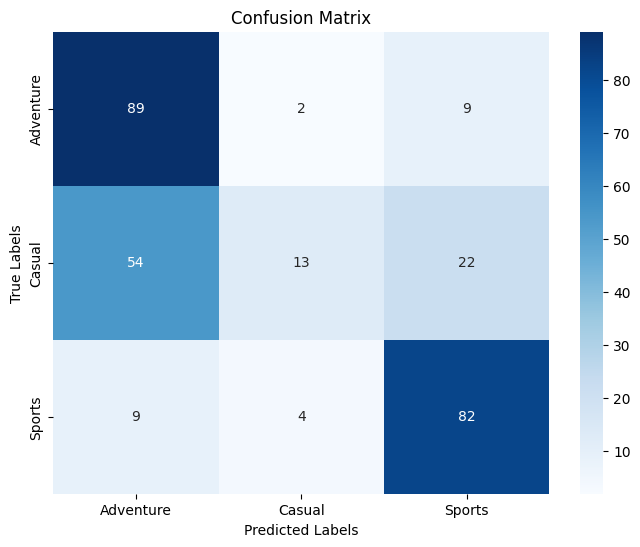

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
labels = ['Adventure', 'Casual', 'Sports']

# Print the confusion matrix to console
print("\nConfusion Matrix:")
print(conf_matrix)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Showing classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)



Classification Report:
              precision    recall  f1-score   support

   adventure       0.59      0.89      0.71       100
      casual       0.68      0.15      0.24        89
       sport       0.73      0.86      0.79        95

    accuracy                           0.65       284
   macro avg       0.67      0.63      0.58       284
weighted avg       0.66      0.65      0.59       284



# Improve menggunakan Pipeline dan GridSearchCV

Using **Pipeline** and **GridSearchCV** together is expected to improve model efficiency and accuracy by automating the process of data transformation and optimal hyperparameter search. Pipeline organizes the workflow into one integrated step—from text vectorization using TF-IDF to classification with Naive Bayes—ensuring consistency between training and testing data. Meanwhile, GridSearchCV tests various combinations of hyperparameters, such as n-gram size and smoothing parameters in Naive Bayes, to find the best settings based on cross-validation results. This combination not only reduces the potential for manual errors in data processing but also improves model performance by automatically optimizing parameters.

In [44]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# Merge the title and description columns that have gone through the stemming process
game_datasets['combined_text'] = game_datasets['title_snowball'].apply(lambda tokens: ' '.join(tokens)) + " " + game_datasets['description_snowball'].apply(lambda tokens: ' '.join(tokens))


In [46]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    game_datasets['combined_text'],
    game_datasets['genre_clean_StopWord'],
    test_size=0.2,
    random_state=42
)

In [47]:
# Performing TF-IDF transformation on X_train and X_test
tfidf_vectorizer = TfidfVectorizer()
X_train = tfidf_vectorizer.fit_transform(X_train_text)
X_test = tfidf_vectorizer.transform(X_test_text)

In [49]:
print(X_test_text.head())

51      black desert go beyond limit world class mmorp...
481     outland outland fastpac dynam platform player ...
806     mad game tycoon build design game studio start...
1260    dakar base world famous annual ralli raid orga...
297     bright memori bright memori lightningfast fusi...
Name: combined_text, dtype: object


In [50]:
# Define a pipeline with TF-IDF and Naive Bayes
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', MultinomialNB())
])

In [51]:
# Define the parameter grid for GridSearch
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],    # Unigram and Bigram
    'tfidf__max_df': [0.7, 0.85],              # Max document frequency to ignore very common words
    'tfidf__min_df': [2, 5],                   # Min document frequency to ignore rare words
    'nb__alpha': [0.5, 1.0]                    # Smoothing parameter for Naive Bayes
}

In [52]:
# Use GridSearchCV to find the best parameters
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_text, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('nb', MultinomialNB())]),
             n_jobs=-1,
             param_grid={'nb__alpha': [0.5, 1.0], 'tfidf__max_df': [0.7, 0.85],
                         'tfidf__min_df': [2, 5],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='accuracy')

In [53]:
# Showing the best parameters and best accuracy of Cross-Validation
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters and Cross-Validation Results:\n")
print(f"- Best Parameters:")
print(f"  - nb__alpha: {best_params['nb__alpha']}")
print(f"  - tfidf__max_df: {best_params['tfidf__max_df']}")
print(f"  - tfidf__min_df: {best_params['tfidf__min_df']}")
print(f"  - tfidf__ngram_range: {best_params['tfidf__ngram_range']}")
print(f"\n- Best Cross-Validation Accuracy: {best_score:.4f}")

Best Parameters and Cross-Validation Results:

- Best Parameters:
  - nb__alpha: 0.5
  - tfidf__max_df: 0.85
  - tfidf__min_df: 5
  - tfidf__ngram_range: (1, 2)

- Best Cross-Validation Accuracy: 0.7193


In [54]:
# Predict on the test set
y_pred = grid_search.predict(X_test_text)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.7464788732394366


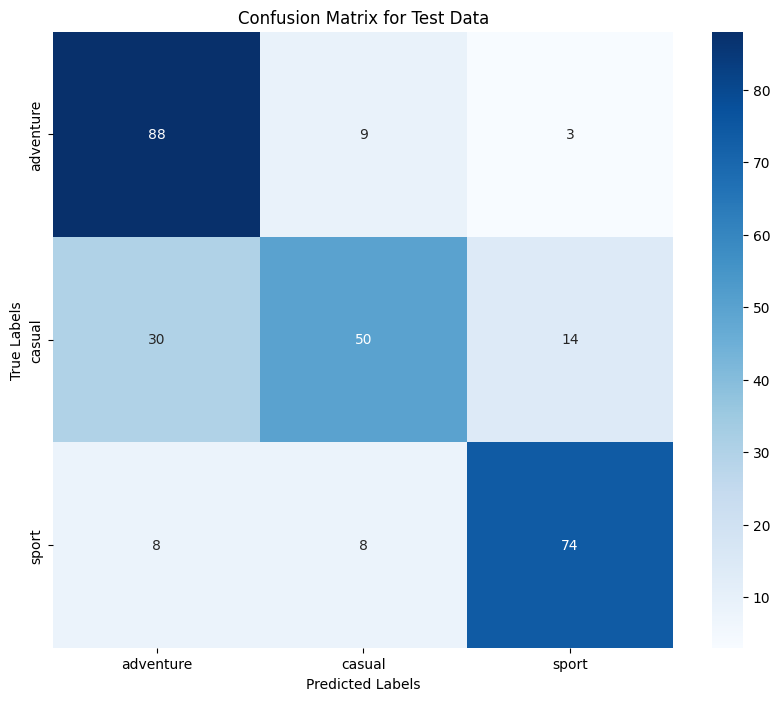

Classification Report for Test Data:
              precision    recall  f1-score   support

   adventure       0.70      0.88      0.78       100
      casual       0.75      0.53      0.62        94
       sport       0.81      0.82      0.82        90

    accuracy                           0.75       284
   macro avg       0.75      0.74      0.74       284
weighted avg       0.75      0.75      0.74       284



In [55]:
# Making predictions on test data (test set)
y_pred = grid_search.predict(X_test_text)

# Creating a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred, labels=grid_search.classes_)

# Displaying confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=grid_search.classes_, yticklabels=grid_search.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for Test Data')
plt.show()

# Displays classification report for test data
print("Classification Report for Test Data:")
print(classification_report(y_test, y_pred))


In [57]:
#Create a DataFrame to compare predicted results with actual data.
results_df = pd.DataFrame({
    'Title and Description': X_test_text.values,
    'Actual Genre': y_test.values,
    'Predicted Genre': y_pred
})

print("Comparison of Title, Description, Actual Genre, and Predicted Genre:")
print(results_df.head(10))

Comparison of Title, Description, Actual Genre, and Predicted Genre:
                               Title and Description Actual Genre  \
0  black desert go beyond limit world class mmorp...    adventure   
1  outland outland fastpac dynam platform player ...    adventure   
2  mad game tycoon build design game studio start...       casual   
3  dakar base world famous annual ralli raid orga...        sport   
4  bright memori bright memori lightningfast fusi...    adventure   
5  timber tenni versus meet timber tenni versus e...        sport   
6  hero evolv featur updat game what hero evolv h...       casual   
7  five night freddi help want five night freddi ...       casual   
8  katamari damaci rerol come soon game stopatnot...       casual   
9  orbit orbit local multiplay game peopl matter ...        sport   

  Predicted Genre  
0       adventure  
1       adventure  
2          casual  
3           sport  
4       adventure  
5           sport  
6           sport  
7          

In [58]:
# Genre Prediction Function for New Data
def predict_genre(title, description):
    combined_text = title + " " + description
    predicted_genre = grid_search.predict([combined_text])
    return predicted_genre[0]

# Example of Genre Prediction on New Data
title_input = "Cosmic Hoops"
description_input = "highly detailed real-time sumulation allows players to feel every muscle twitch and heartbeat as thes race against the clock and opponents in a dynamic, ever changing environment"
predicted_genre = predict_genre(title_input, description_input)
print("Predicted Genre:", predicted_genre)

Predicted Genre: sport


In [59]:
# Genre Prediction Function for New Data
def predict_genre(title, description):
    combined_text = title + " " + description
    predicted_genre = grid_search.predict([combined_text])
    return predicted_genre[0]

# Example of Genre Prediction on New Data
title_input = "Cat Cafe"
description_input = "menage the most unique cat cafe in town! take care of cute cats, make all kinds of delicious food and drinks, and decorate the cafe with adorable furniture to attract costumers"
predicted_genre = predict_genre(title_input, description_input)
print("Predicted Genre:", predicted_genre)

Predicted Genre: casual
